In [1]:
import slangpy as spy
import numpy as np
import matplotlib.pyplot as plt

from bvhgs import device
from bvhgs import gaussian_module

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
np.random.seed(0)

In [3]:
test_module = device.load_module("tests.slang")

In [4]:
render_prog = device.link_program([test_module], [test_module.entry_point("renderGaussian2D")])
render_ker = device.create_compute_kernel(render_prog)

In [5]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    width=64,
    height=64,
    usage=spy.TextureUsage.shader_resource|spy.TextureUsage.unordered_access
)

In [6]:
position = np.random.uniform(low=0.3, high=0.7, size=(3)).astype(np.float32)
covariance = np.random.randn(2, 2).astype(np.float32)
cov = np.dot(covariance, covariance.T) * 0.002
color = np.random.rand(3).astype(np.float32)
opacity = np.random.rand(1).astype(np.float32)
gaussian = gaussian_module.Gaussian2D(
    position=spy.float3(*position),
    covariance=spy.float2x2(cov.flatten()),
    color=spy.float3(*color),
    opacity=opacity.item(),
)
gaussian

{'position': {0.5195254, 0.5860757, 0.54110533},
 'covariance': {{0.013847313, 0.009077118}, {0.009077118, 0.009181572}},
 'color': {0.891773, 0.96366274, 0.3834415},
 'opacity': 0.7917250394821167,
 'cachedInvCov': {{205.19296, -202.85858}, {-202.85858, 309.46457}}}

In [7]:
render_ker.dispatch(
    thread_count=[64, 64, 1],
    renderTarget=render_target,
    g=gaussian
)

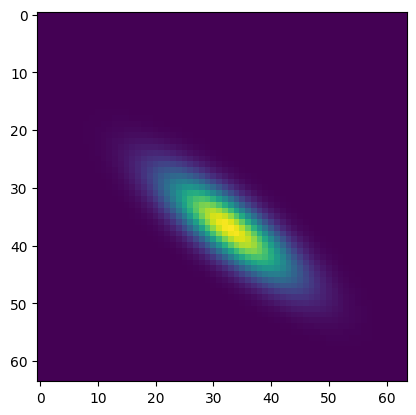

In [8]:
plt.imshow(render_target.to_numpy())